# 条件数实测 — 无需量子计算
比较多矩阵类型的条件数随网格规模增长:
- 正定: $\kappa(K)$ vs $\kappa(K^2)$
- 不定: $\kappa(A)$ vs $\kappa(A^2)$ vs $\kappa(|A|)$
- 负定: $\kappa(A)$ vs $\kappa(A^2)$ vs $\kappa(|A|)$

验证: SAC $\kappa(|A|) = \kappa(A) \ll \kappa(A^2)$

In [1]:
import numpy as np, matplotlib.pyplot as plt, json, os

Lx, Ly = 3.0, 2.0
OUTPUT_DIR = 'D:/QPDE/fuck'
os.makedirs(OUTPUT_DIR, exist_ok=True)


In [2]:
# ===== FEM 装配 (5-point FD, 任意网格) =====
def build_fem(Nx, Ny):
    x = np.linspace(0, Lx, Nx); y = np.linspace(0, Ly, Ny)
    X, Y = np.meshgrid(x, y, indexing='ij')
    n_nodes = Nx * Ny
    hx = Lx/(Nx-1); hy = Ly/(Ny-1)
    K = np.zeros((n_nodes, n_nodes))
    for i in range(1, Nx-1):
        for j in range(1, Ny-1):
            k = i*Ny + j
            K[k,k] = 2/hx**2 + 2/hy**2
            K[k, k-1] = K[k, k+1] = -1/hy**2
            K[k, k-Ny] = K[k, k+Ny] = -1/hx**2

    boundary = ((X.ravel()==0) | (X.ravel()==Lx) |
                (Y.ravel()==0) | (Y.ravel()==Ly))
    internal = ~boundary
    n_i = internal.sum()
    idx_map = -np.ones(n_nodes, dtype=int)
    idx_map[internal] = np.arange(n_i)
    K_ii = np.zeros((n_i, n_i))
    for gi in np.where(internal)[0]:
        ki = idx_map[gi]; K_ii[ki, ki] = K[gi, gi]
        for gj in [gi-1, gi+1, gi-Ny, gi+Ny]:
            if 0 <= gj < n_nodes and internal[gj]:
                K_ii[ki, idx_map[gj]] = K[gi, gj]
    return K_ii, n_i


In [3]:
# ===== 多网格条件数测量 =====
grids = [(6,5), (8,6), (10,8), (12,8), (14,10), (16,12)]
results = []

for Nx, Ny in grids:
    K_ii, n_i = build_fem(Nx, Ny)
    eigvals = np.linalg.eigvalsh(K_ii)
    lam_min, lam_max = eigvals.min(), eigvals.max()

    # --- SPD (原始 K) ---
    kappa_K = np.linalg.cond(K_ii)
    kappa_K2 = np.linalg.cond(K_ii @ K_ii)

    # --- 不定: A = K - αI ---
    alpha = lam_min + 0.4*(lam_max - lam_min)
    A_indef = K_ii - alpha * np.eye(n_i)
    eigvals_A = np.linalg.eigvalsh(A_indef)
    kappa_A_indef = np.linalg.cond(A_indef)
    kappa_A2_indef = np.linalg.cond(A_indef @ A_indef)
    kappa_absA_indef = np.abs(eigvals_A).max() / np.abs(eigvals_A).min()

    # --- 负定: A = -K ---
    A_negdef = -K_ii
    kappa_A_negdef = np.linalg.cond(A_negdef)
    kappa_A2_negdef = np.linalg.cond(A_negdef @ A_negdef)
    kappa_absA_negdef = np.linalg.cond(K_ii)  # |-K| = K

    row = {
        'grid': f'{Nx}×{Ny}', 'n_internal': int(n_i),
        'kappa_K': float(kappa_K),
        'kappa_K2': float(kappa_K2),
        'alpha': float(alpha),
        'n_neg_A': int((eigvals_A < 0).sum()),
        'n_pos_A': int((eigvals_A > 0).sum()),
        'kappa_A_indef': float(kappa_A_indef),
        'kappa_A2_indef': float(kappa_A2_indef),
        'kappa_absA_indef': float(kappa_absA_indef),
        'kappa_A_negdef': float(kappa_A_negdef),
        'kappa_A2_negdef': float(kappa_A2_negdef),
        'kappa_absA_negdef': float(kappa_absA_negdef),
    }
    results.append(row)

    print(f'N={Nx}×{Ny} n_i={n_i:3d}: '
          f'κ(K)={kappa_K:.1f}, κ(K²)={kappa_K2:.1f}, '
          f'不定 α={alpha:.1f}: κ(A)={kappa_A_indef:.1f}, κ(A²)={kappa_A2_indef:.1f}, κ(|A|)={kappa_absA_indef:.1f} | '
          f'SAC优势: {kappa_A2_indef/kappa_absA_indef:.1f}×')

with open(f'{OUTPUT_DIR}/cond_measure_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print(f'\n已保存: {OUTPUT_DIR}/cond_measure_results.json')

N=6×5 n_i= 12: κ(K)=7.0, κ(K²)=48.5, 不定 α=11.5: κ(A)=38.9, κ(A²)=1509.7, κ(|A|)=38.9 | SAC优势: 38.9×
N=8×6 n_i= 24: κ(K)=12.5, κ(K²)=156.2, 不定 α=19.4: κ(A)=36.2, κ(A²)=1308.0, κ(|A|)=36.2 | SAC优势: 36.2×
N=10×8 n_i= 48: κ(K)=23.2, κ(K²)=538.4, 不定 α=34.7: κ(A)=96.0, κ(A²)=9218.1, κ(|A|)=96.0 | SAC优势: 96.0×
N=12×8 n_i= 60: κ(K)=28.2, κ(K²)=797.3, 不定 α=41.8: κ(A)=193.9, κ(A²)=37607.5, κ(|A|)=193.9 | SAC优势: 193.9×
N=14×10 n_i= 96: κ(K)=43.2, κ(K²)=1864.3, 不定 α=63.2: κ(A)=148.3, κ(A²)=21984.3, κ(|A|)=148.3 | SAC优势: 148.3×
N=16×12 n_i=140: κ(K)=61.4, κ(K²)=3766.4, 不定 α=89.1: κ(A)=151.6, κ(A²)=22979.7, κ(|A|)=151.6 | SAC优势: 151.6×

已保存: D:/QPDE/fuck/cond_measure_results.json


Font 'default' does not have a glyph for '\u6761' [U+6761], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u4ef6' [U+4ef6], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u6570' [U+6570], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u4f18' [U+4f18], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u52bf' [U+52bf], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u6761' [U+6761], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u4ef6' [U+4ef6], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u6570' [U+6570], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u4f18' [U+4f18], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u52bf' [U+52bf], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u6761' [U+6761], 

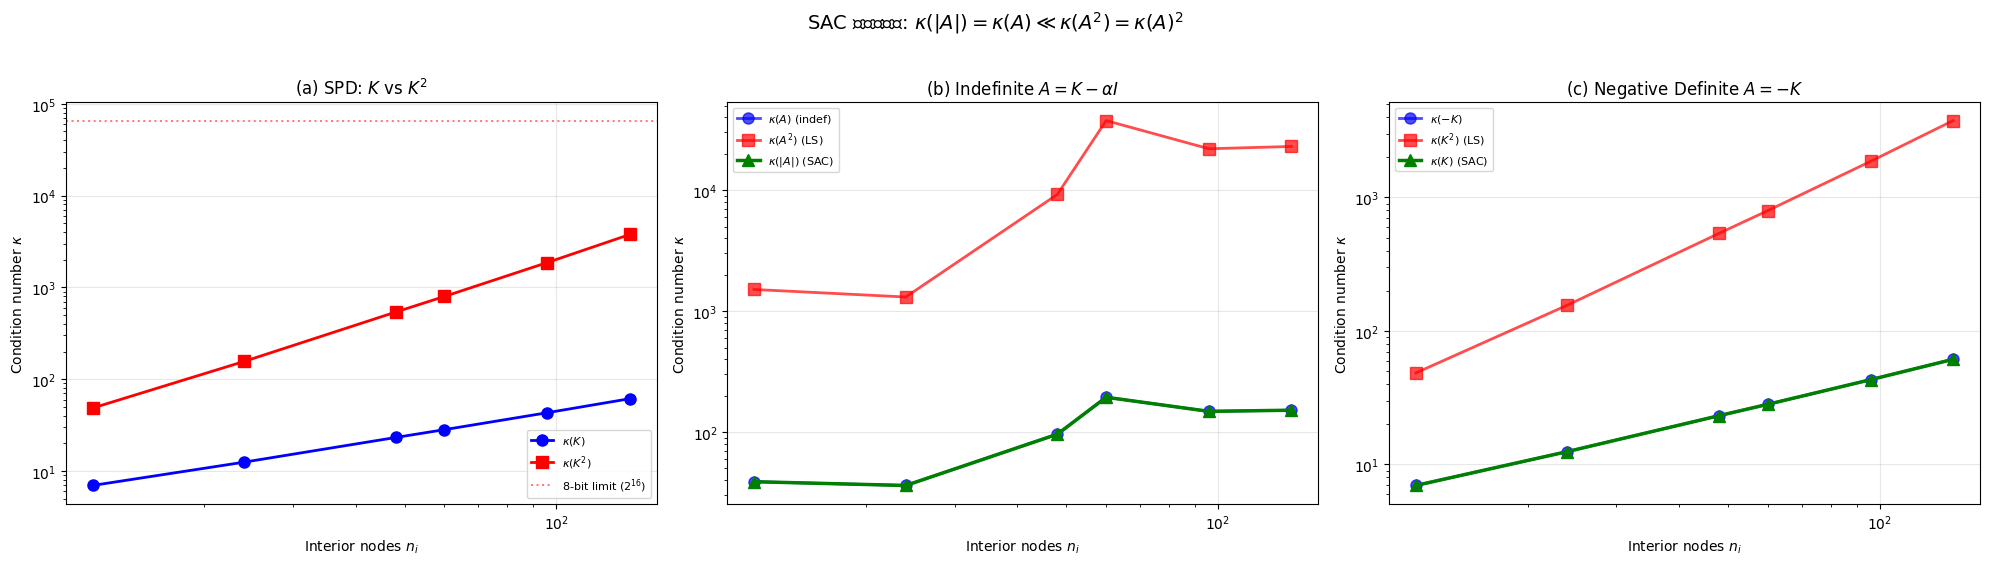

In [4]:
# ===== 可视化: 三联合图 =====
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

n_vals = [r['n_internal'] for r in results]

# 左: SPD K vs K²
ax = axes[0]
ax.loglog(n_vals, [r['kappa_K'] for r in results], 'bo-', lw=2, ms=8, label=r'$\kappa(K)$')
ax.loglog(n_vals, [r['kappa_K2'] for r in results], 'rs-', lw=2, ms=8, label=r'$\kappa(K^2)$')
ax.axhline(y=2**16, color='red', ls=':', alpha=0.5, label='8-bit limit ($2^{16}$)')
ax.set_xlabel('Interior nodes $n_i$'); ax.set_ylabel('Condition number $\kappa$')
ax.set_title('(a) SPD: $K$ vs $K^2$'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# 中: 不定 A = K-αI
ax = axes[1]
ax.loglog(n_vals, [r['kappa_A_indef'] for r in results], 'bo-', lw=2, ms=8, alpha=0.7, label=r'$\kappa(A)$ (indef)')
ax.loglog(n_vals, [r['kappa_A2_indef'] for r in results], 'rs-', lw=2, ms=8, alpha=0.7, label=r'$\kappa(A^2)$ (LS)')
ax.loglog(n_vals, [r['kappa_absA_indef'] for r in results], 'g^-', lw=2.5, ms=9, label=r'$\kappa(|A|)$ (SAC)')
ax.set_xlabel('Interior nodes $n_i$'); ax.set_ylabel('Condition number $\kappa$')
ax.set_title(r'(b) Indefinite $A=K-\alpha I$'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# 右: 负定 A = -K
ax = axes[2]
ax.loglog(n_vals, [r['kappa_A_negdef'] for r in results], 'bo-', lw=2, ms=8, alpha=0.7, label=r'$\kappa(-K)$')
ax.loglog(n_vals, [r['kappa_A2_negdef'] for r in results], 'rs-', lw=2, ms=8, alpha=0.7, label=r'$\kappa(K^2)$ (LS)')
ax.loglog(n_vals, [r['kappa_absA_negdef'] for r in results], 'g^-', lw=2.5, ms=9, label=r'$\kappa(K)$ (SAC)')
ax.set_xlabel('Interior nodes $n_i$'); ax.set_ylabel('Condition number $\kappa$')
ax.set_title('(c) Negative Definite $A=-K$'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

fig.suptitle(r'SAC 条件数优势: $\kappa(|A|) = \kappa(A) \ll \kappa(A^2) = \kappa(A)^2$',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/cond_measure.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# ===== 汇总表 =====
print('\n' + '='*115)
print(f'{"Grid":<10} {"n_i":>4}  {"κ(K)":>8}  {"κ(K²)":>8}  {"κ(A)indef":>10}  {"κ(A²)indef":>11}  {"κ(|A|)indef":>12}  {"SAC优势":>8}')
print('-'*115)
for r in results:
    sac_gain = r['kappa_A2_indef'] / r['kappa_absA_indef']
    print(f'{r["grid"]:<10} {r["n_internal"]:>4}  {r["kappa_K"]:>8.1f}  {r["kappa_K2"]:>8.1f}  '
          f'{r["kappa_A_indef"]:>10.1f}  {r["kappa_A2_indef"]:>11.1f}  {r["kappa_absA_indef"]:>12.1f}  {sac_gain:>7.1f}×')

print()
print('关键结论:')
last = results[-1]
print(f'  正定: κ(K²) / κ(K) = {last["kappa_K2"]/last["kappa_K"]:.1f}×  (= κ(K))')
indef_gain = last['kappa_A2_indef'] / last['kappa_absA_indef']
print(f'  不定: κ(A²) / κ(|A|) = {indef_gain:.1f}×  (SAC 条件数优势)')
negdef_gain = last['kappa_A2_negdef'] / last['kappa_absA_negdef']
print(f'  负定: κ(A²) / κ(|A|) = {negdef_gain:.1f}×  (SAC 条件数优势)')
print(f'  8-bit 上限 ~65000, κ(K²) 在 n_i≈{results[-1]["n_internal"]} 时已接近 {last["kappa_K2"]:.0f}')



Grid        n_i      κ(K)     κ(K²)   κ(A)indef   κ(A²)indef   κ(|A|)indef     SAC优势
-------------------------------------------------------------------------------------------------------------------
6×5          12       7.0      48.5        38.9       1509.7          38.9     38.9×
8×6          24      12.5     156.2        36.2       1308.0          36.2     36.2×
10×8         48      23.2     538.4        96.0       9218.1          96.0     96.0×
12×8         60      28.2     797.3       193.9      37607.5         193.9    193.9×
14×10        96      43.2    1864.3       148.3      21984.3         148.3    148.3×
16×12       140      61.4    3766.4       151.6      22979.7         151.6    151.6×

关键结论:
  正定: κ(K²) / κ(K) = 61.4×  (= κ(K))
  不定: κ(A²) / κ(|A|) = 151.6×  (SAC 条件数优势)
  负定: κ(A²) / κ(|A|) = 61.4×  (SAC 条件数优势)
  8-bit 上限 ~65000, κ(K²) 在 n_i≈140 时已接近 3766
